##### Importing all necessary libraries first

In [13]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_aer.primitives import Sampler

# Set random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

#####  Load and Preprocess Data

In [14]:
#Loading the data
df = pd.read_csv('data/creditcard.csv')

In [15]:
# Balance the dataset (Undersampling)
# There are only ~492 fraud cases. We will match them with 492 valid cases.
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0].sample(n=len(fraud), random_state=42)
balanced_df = pd.concat([fraud, valid]).sample(frac=1, random_state=42)

In [16]:
# Further subset to 200 total samples so the Quantum Simulator runs in seconds, not hours
subset_df = balanced_df.sample(n=200, random_state=42)

In [17]:
X = subset_df.drop('Class', axis=1)
y = subset_df['Class']

In [18]:
# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# Applying PCA (Reducing to 4 features for 4 Qubits)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

In [20]:
# Spliting the data into Train and Test sets in 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [22]:
# Display the train and test sets
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (160, 4)
Testing features shape: (40, 4)


##### Train & Evaluate Classical SVM (Baseline) model

In [24]:
# Train Classical SVM with an RBF Kernel
classical_svc = SVC(kernel='rbf')
classical_svc.fit(X_train, y_train)

# Predict
c_predictions = classical_svc.predict(X_test)

# Evaluate
print("Classical SVM Classification Report:")
print(classification_report(y_test, c_predictions))

Classical SVM Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        22

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



##### Set up the Quantum Kernel

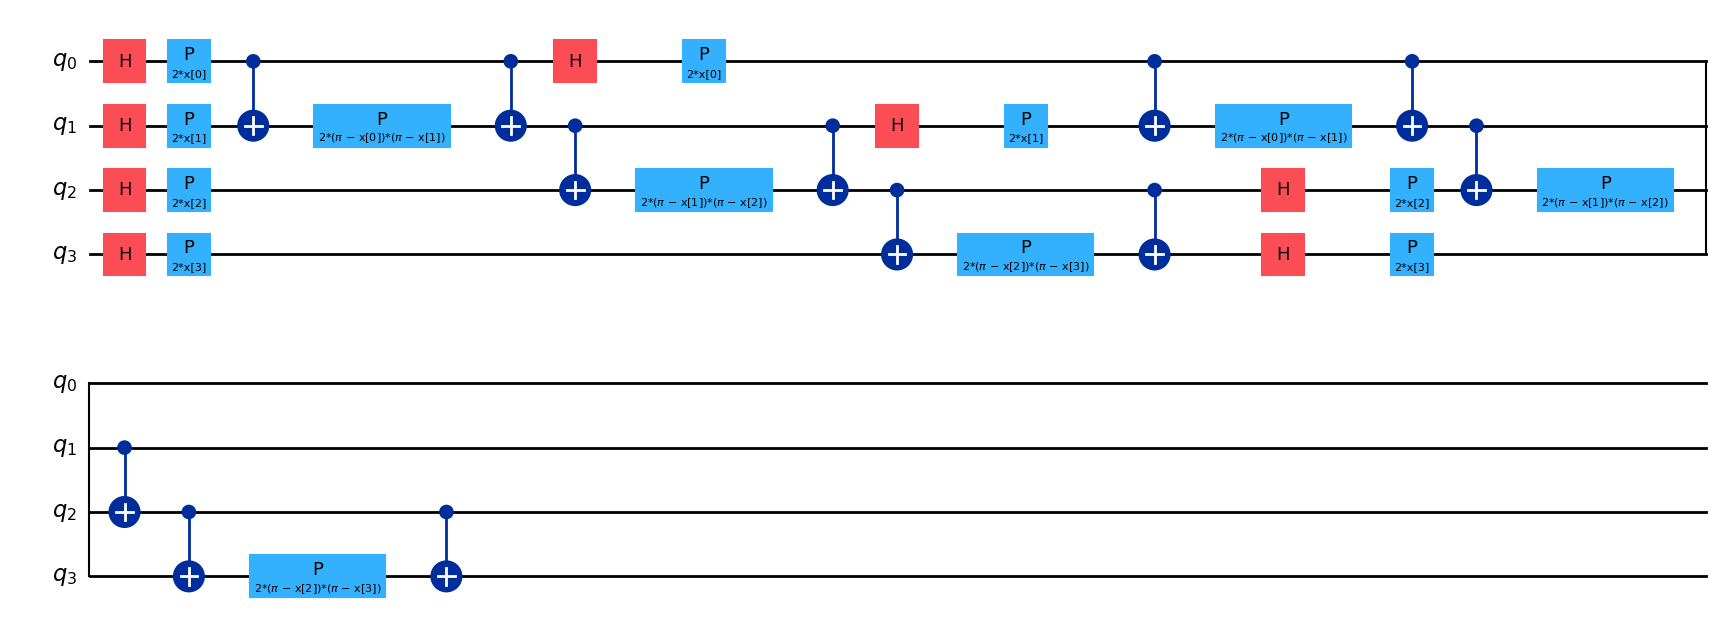

Quantum Kernel mapped successfully!


In [25]:
# Define the number of features (which equals the number of qubits)
num_features = X_train.shape[1]

# Define Quantum Feature Map
# The ZZFeatureMap is great for making data non-linearly separable
feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2, entanglement='linear')

# Plot the circuit
display(feature_map.decompose().draw(output='mpl'))

# Set up the Sampler (Using Aer simulator for speed)
sampler = Sampler()

# Create the Quantum Kernel
qkernel = FidelityQuantumKernel(feature_map=feature_map)

print("Quantum Kernel mapped successfully!")

##### Train & Evaluate Quantum SVM

In [26]:
# Train QSVM using the Quantum Kernel
qsvm = SVC(kernel=qkernel.evaluate)
qsvm.fit(X_train, y_train)

# Predict
q_predictions = qsvm.predict(X_test)

# Evaluate
print("Quantum SVM Classification Report:")
print(classification_report(y_test, q_predictions))

Quantum SVM Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.56      0.59        18
           1       0.67      0.73      0.70        22

    accuracy                           0.65        40
   macro avg       0.65      0.64      0.64        40
weighted avg       0.65      0.65      0.65        40



##### Visualizing the Confusion Matrices

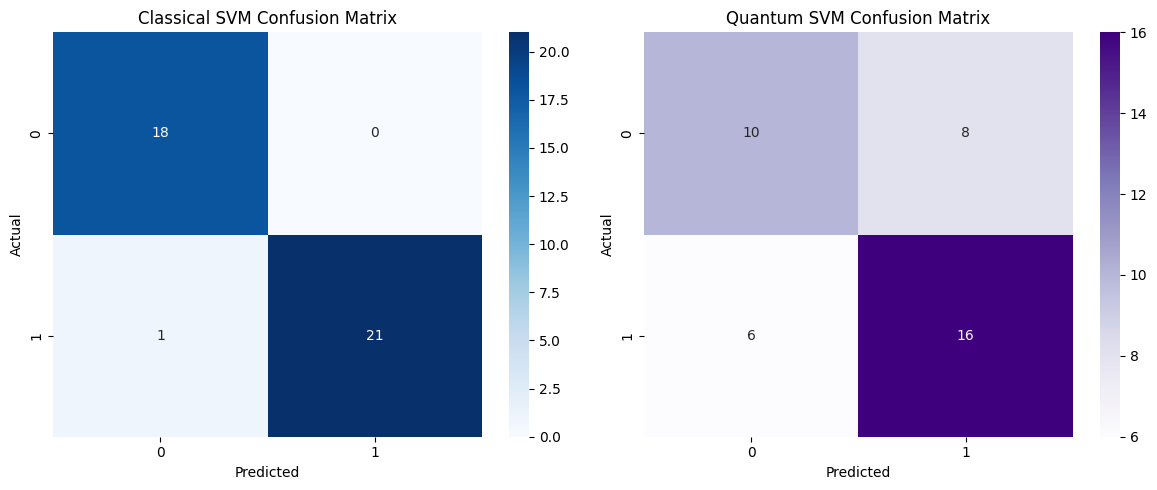

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Classical Confusion Matrix
cm_classical = confusion_matrix(y_test, c_predictions)
sns.heatmap(cm_classical, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Classical SVM Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Quantum Confusion Matrix
cm_quantum = confusion_matrix(y_test, q_predictions)
sns.heatmap(cm_quantum, annot=True, fmt='d', cmap='Purples', ax=ax[1])
ax[1].set_title('Quantum SVM Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()